# Preprocessing & Feature Engineering
This notebook is for preprocessing the data and selection of important features

---
### Steps:
1. Setting Up Environment
2. Load Dataset
3. Drop Duplicates & Constant Feature
4. Encoding
5. Data Splitting
6. Class Imbalance
7. Feature Scaling

## 1. Setting Up Environment

In [1]:
#-----------------imports------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder , StandardScaler
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='flare', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})

path = '/Users/wadalisam/Documents/GitHub/insider-threat-detector/data/raw/insider_threat_dataset.csv'
models_dir = '/Users/wadalisam/Documents/GitHub/insider-threat-detector/models/'
random_state = 42

os.makedirs(models_dir , exist_ok=True)
print("Set Up Complete")

Set Up Complete


## 2. Load Dataset

In [2]:
data = pd.read_csv(path)
print(f"Loaded: {data.shape[0]:,} rows x {data.shape[1]} columns")
data.head(3)

Loaded: 118,614 rows x 22 columns


,employee_department,employee_campus,employee_position,employee_seniority_years,is_contractor,employee_classification,has_foreign_citizenship,has_criminal_record,has_medical_history,employee_origin_country,...,total_files_burned,burned_from_other,is_abroad,trip_day_number,hostility_country_level,num_entries,num_unique_campus,late_exit_flag,entry_during_weekend,is_malicious
0,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,4,0,0,0.0,0,1,1,0,1,0
1,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,0,0,0.0,0,1,1,0,0,0
2,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,2,0,0,0.0,0,1,1,0,0,0


## 3. Drop Duplicates and Constant Feature

In [3]:
data = data.drop_duplicates()
#dropping late_exit_flag it has zero-variance from data exploration
data = data.drop(columns=['late_exit_flag'])

## 4. Encode Categorical Features

In [4]:
cat_cols = ['employee_department', 'employee_campus',
            'employee_position', 'employee_origin_country']

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    encoders[col] = le
    print(f'{col}: {len(le.classes_)} classes → encoded as integers 0–{len(le.classes_)-1}')

# Persist encoders
with open(f'{models_dir}encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

print('\nEncoders saved.')
data.head(3)

employee_department: 11 classes → encoded as integers 0–10
employee_campus: 3 classes → encoded as integers 0–2
employee_position: 48 classes → encoded as integers 0–47
employee_origin_country: 32 classes → encoded as integers 0–31

Encoders saved.


,employee_department,employee_campus,employee_position,employee_seniority_years,is_contractor,employee_classification,has_foreign_citizenship,has_criminal_record,has_medical_history,employee_origin_country,...,num_printed_pages_off_hours,total_files_burned,burned_from_other,is_abroad,trip_day_number,hostility_country_level,num_entries,num_unique_campus,entry_during_weekend,is_malicious
0,0,2,15,22,0,2,0,0,0,6,...,0,4,0,0,0.0,0,1,1,1,0
1,0,2,15,22,0,2,0,0,0,6,...,0,0,0,0,0.0,0,1,1,0,0
2,0,2,15,22,0,2,0,0,0,6,...,0,2,0,0,0.0,0,1,1,0,0


## 5. Data Split

In [5]:
# Shuffle all rows and reset the index
data = data.sample(frac=1, random_state=random_state).reset_index(drop=True)

X = data.drop(columns=['is_malicious'])
y = data['is_malicious']

feature_names = list(X.columns)

print(f'Features ({len(feature_names)}) : {feature_names}')
print(f'Target: is_malicious : {dict(y.value_counts())}')

with open(f'{models_dir}feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names,f)

#split with stratified 80/20 to preserve the malicious class
X_train , X_test , y_train, y_test = train_test_split(X,y,test_size=0.2, random_state = random_state, stratify=y)
print(f'Training set:  {len(X_train):,} rows | Malicious: {y_train.sum():,} ({y_train.mean()*100:.2f}%)')
print(f'Test set:      {len(X_test):,} rows  | Malicious: {y_test.sum():,}  ({y_test.mean()*100:.2f}%)')

Features (20) : ['employee_department', 'employee_campus', 'employee_position', 'employee_seniority_years', 'is_contractor', 'employee_classification', 'has_foreign_citizenship', 'has_criminal_record', 'has_medical_history', 'employee_origin_country', 'total_printed_pages', 'num_printed_pages_off_hours', 'total_files_burned', 'burned_from_other', 'is_abroad', 'trip_day_number', 'hostility_country_level', 'num_entries', 'num_unique_campus', 'entry_during_weekend']
Target: is_malicious : {0: np.int64(112228), 1: np.int64(6386)}
Training set:  94,891 rows | Malicious: 5,109 (5.38%)
Test set:      23,723 rows  | Malicious: 1,277  (5.38%)


## 6. Class Imbalance

Before SMOTE:
  Normal (0):    89,782
  Malicious (1): 5,109

After SMOTE:
  Normal (0):    89,782
  Malicious (1): 89,782
  Total:         179,564


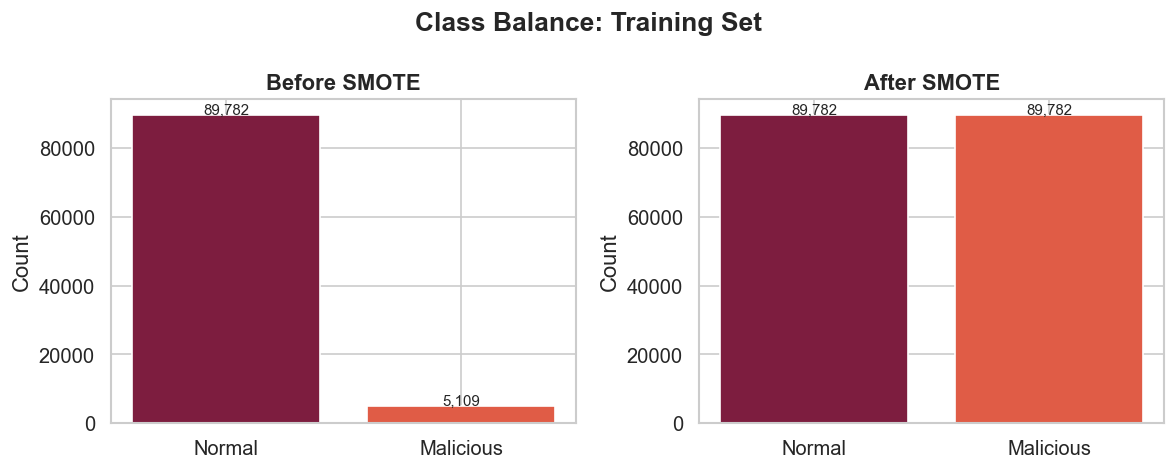

In [6]:
print('Before SMOTE:')
print(f'  Normal (0):    {(y_train==0).sum():,}')
print(f'  Malicious (1): {(y_train==1).sum():,}')

sm = SMOTE(random_state=random_state)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print('\nAfter SMOTE:')
print(f'  Normal (0):    {(y_train_res==0).sum():,}')
print(f'  Malicious (1): {(y_train_res==1).sum():,}')
print(f'  Total:         {len(X_train_res):,}')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, counts, title in [
    (axes[0], pd.Series(y_train).value_counts(),     'Before SMOTE'),
    (axes[1], pd.Series(y_train_res).value_counts(), 'After SMOTE')
]:
    ax.bar(['Normal', 'Malicious'], counts.values, color=['#7d1d3f','#e05c46'], edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=9)
plt.suptitle('Class Balance: Training Set', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Feature Scaling

In [7]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)

print('---------------------Scaling Complete------------------------------------')
print(f'Training scaled shape: {X_train_sc.shape}')

with open(f'{models_dir}scaler.pkl','wb') as f:
    pickle.dump(scaler,f)

---------------------Scaling Complete------------------------------------
Training scaled shape: (179564, 20)


## 8. Save Processed Data

In [8]:
splits = {
    'X_train':    X_train_res,   # SMOTE-resampled training features
    'X_train_sc': X_train_sc,    # scaled version for Logistic Regression
    'y_train':    y_train_res,   # SMOTE-resampled training labels
    'X_test':     X_test,        # raw test features (never SMOTE'd)
    'y_test':     y_test,        # raw test labels
}

with open(f'{models_dir}splits.pkl', 'wb') as f:
    pickle.dump(splits, f)
